# Project 1

## Introduction
This notebook contains the development of a mini project conducted in the University of Crete for the course of Pattern Recognition. It develops a deep understanding of Bayesian Decision Theory by implementing a generative classifier from scratch.

### Import Libraries

In [1]:
import numpy as np
from scipy import linalg as LA
import pandas as pd
import matplotlib.pyplot as plt

### Creating similar Test Dataset to visualize the plot.

In [2]:
#------------------------- Test Dataset for plotting -------------------------
means = [
    [13.74, 5.53], # Class 0
    [12.28, 3.09], # Class 1
    [13.15, 7.40]  # Class 2
]

covs = [
    [[0.21, 0.23], [0.23, 1.53]], 
    [[0.29, 0.13], [0.13, 0.86]], 
    [[0.28, 0.43], [0.43, 5.34]]
]

data_list = []
for i in range(3):
    samples = np.random.multivariate_normal(means[i], covs[i], 30)
    temp_df = pd.DataFrame(samples, columns=["alcohol", "color_intensity"])
    temp_df['labels'] = i
    data_list.append(temp_df)

df_final = pd.concat(data_list).sample(frac=1).reset_index(drop=True)
df_final.to_csv('data.csv', index=False)
print("Synthetic dataset 'data.csv' created with alcohol and color_intensity.")


#------------------------------ End of Test Dataset ----------------------

Synthetic dataset 'data.csv' created with alcohol and color_intensity.


### Computation of fundamental statistical measures (mean, variance).

In [10]:
#df=pd.read_csv('data.csv',usecols=["alcohol","color_intensity"])
#df1=pd.read_csv('data.csv')
points = df_final[["alcohol", "color_intensity"]].values.tolist()
nsamples = np.array([30, 30, 30]) 
total = np.sum(nsamples)
randompoint = np.array([1, 1])

mean0 = np.array([13.74, 5.53])
mean1 = np.array([12.28, 3.09])
mean2 = np.array([13.15, 7.40])

covs0 = np.array([[0.21, 0.23], [0.23, 1.53]])
covs1 = np.array([[0.29, 0.13], [0.13, 0.86]])
covs2 = np.array([[0.28, 0.43], [0.43, 5.34]])

prices = np.array([
    [0, 12/10, 14/10],
    [10/12, 0, 14/12],
    [10/14, 12/14, 0]
])

### Calculating the Prior, Likelihood and Posterior Probabillity for each class. 

In [11]:
#Prior Probability
def prior(k):
    priors = nsamples / total
    return priors[k]

#Likelihood for each sample using the PDF of normal distribution 
def likelihood(sample, cov, mean):
    x = sample - mean
    inv_cov = np.linalg.inv(cov)
    exponent = -0.5 * (x.T @ inv_cov @ x)
    det = np.linalg.det(cov)
    norm_const = 1 / (2 * np.pi * np.sqrt(det))
    return norm_const * np.exp(exponent)

def likelihoodclass(k):
    #Mapping the correct mean and covariance to the class index 
    if k == 0: return np.apply_along_axis(likelihood, 1, points, covs0, mean0)
    if k == 1: return np.apply_along_axis(likelihood, 1, points, covs1, mean1)
    if k == 2: return np.apply_along_axis(likelihood, 1, points, covs2, mean2)

#Posterior Probability 
def posterior():
    l0 = likelihoodclass(0)
    l1 = likelihoodclass(1)
    l2 = likelihoodclass(2)
    
    posteriors = np.zeros((90, 3))
    for i in range(90):
        evidence = (l0[i] * prior(0)) + (l1[i] * prior(1)) + (l2[i] * prior(2))
        posteriors[i, 0] = (l0[i] * prior(0)) / evidence
        posteriors[i, 1] = (l1[i] * prior(1)) / evidence
        posteriors[i, 2] = (l2[i] * prior(2)) / evidence
    return posteriors

Posterior = posterior()
predicted_classes = np.argmax(Posterior, axis=1)
real_classes = df_final["labels"].values 
accuracy = np.mean(predicted_classes == real_classes)

print("Predicted Classes:", predicted_classes)
print("Real Classes:     ", real_classes)
print("Accuracy:          ", accuracy)

Predicted Classes: [1 0 1 1 2 2 1 2 1 0 0 2 1 1 1 2 0 0 2 2 0 0 0 2 2 1 1 0 2 2 1 2 2 2 1 1 2
 1 0 1 2 0 1 0 0 0 1 1 2 1 0 2 0 1 1 1 1 0 0 1 1 1 0 1 2 2 2 2 1 2 0 0 1 1
 1 1 1 1 0 1 0 0 2 2 1 1 2 0 0 1]
Real Classes:      [1 0 1 1 2 2 1 2 1 0 0 2 0 1 1 2 0 0 2 2 0 0 0 2 0 1 1 0 0 2 1 2 2 2 1 1 2
 0 0 1 2 1 2 0 0 0 1 2 2 0 0 2 0 1 1 0 0 2 0 1 2 2 0 1 2 2 2 0 1 2 0 0 1 1
 2 1 1 1 0 1 0 1 2 2 1 1 2 2 0 1]
Accuracy:           0.8111111111111111


### Calculating the Contitional Risk

In [13]:
#Conditional Risk
def conditional_risk(prices):
  for i in range(90):
    conditional_risks=np.sum(prices*Posterior[i],axis=1)
  return conditional_risks

predicted_labels=np.argmin(conditional_risk(prices))
accuracy1=np.mean(predicted_labels==real_classes)
print(conditional_risk(prices))
print(accuracy1)

[1.20405343 0.02454623 0.8391629 ]
0.3333333333333333


### Plotting 2D space including mean and decision boundaries for each class.  

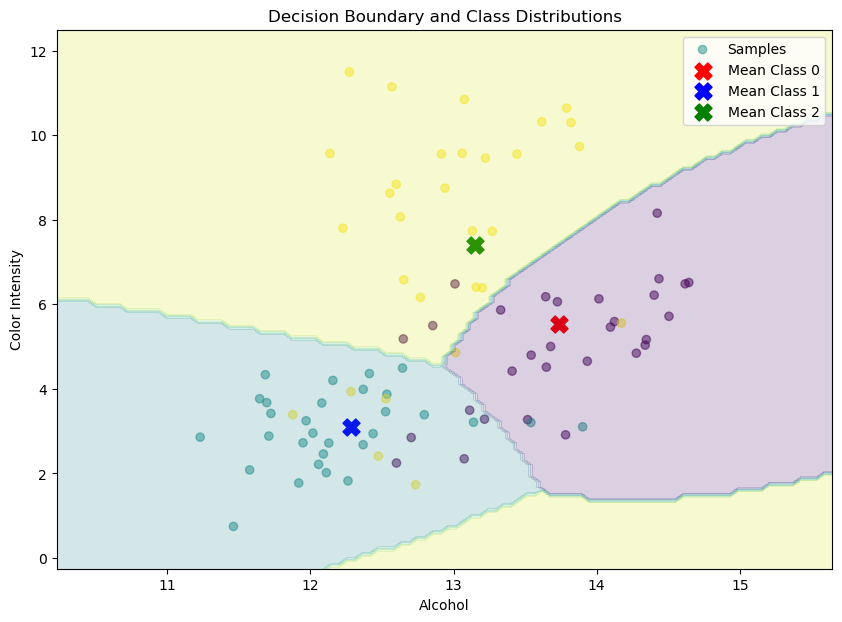

In [16]:
plt.figure(figsize=(10, 7))
plt.scatter(df_final["alcohol"], df_final["color_intensity"], c=real_classes, cmap='viridis', alpha=0.5, label='Samples')

#Plot the means of each class 
plt.scatter(mean0[0], mean0[1], color='red', marker='X', s=150, label='Mean Class 0')
plt.scatter(mean1[0], mean1[1], color='blue', marker='X', s=150, label='Mean Class 1')
plt.scatter(mean2[0], mean2[1], color='green', marker='X', s=150, label='Mean Class 2')

#Plot the decision boundary 
#Create a mesh grid
x_min, x_max = df_final["alcohol"].min() - 1, df_final["alcohol"].max() + 1
y_min, y_max = df_final["color_intensity"].min() - 1, df_final["color_intensity"].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

#Calculate likelihoods for the grid points to determine boundaries
def get_grid_predictions(grid_pts):
    l0 = np.apply_along_axis(likelihood, 1, grid_pts, covs0, mean0) * prior(0)
    l1 = np.apply_along_axis(likelihood, 1, grid_pts, covs1, mean1) * prior(1)
    l2 = np.apply_along_axis(likelihood, 1, grid_pts, covs2, mean2) * prior(2)
    return np.argmax(np.stack([l0, l1, l2]), axis=0)

Z = get_grid_predictions(grid_points)
Z = Z.reshape(xx.shape)

#Plot the decision regions
plt.contourf(xx, yy, Z, alpha=0.2, cmap='viridis')
plt.title("Decision Boundary and Class Distributions")
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")
plt.legend()
plt.show()

## Results
### Evaluation
The evaluation of the project is based on the synthetic Dataset that we made. The model achieved high classification accuracy of approximately 81.11%, demonstrating that the features 'Alcohol' and 'Color Intensity' provide significant discriminative power for the three classes.

### Conditional Risk evaluation
When applying the Conditional Risk minimization rule, the accuracy shifted to 33.33%. This lower numerical accuracy is expected when using a custom loss matrix, as the classifier is no longer optimizing for the most likely class, but rather for the decision that minimizes total "cost" based on the defined penalties.

### Visualization
The scatter plot indicates that while Class 1 (blue) is relatively well-separated, there is noticeable overlap between Class 0 (purple) and Class 2 (yellow). The decision boundaries are non-linear (quadratic), which is a direct result of using full covariance matrices for each class. The data appears moderately separable, but the overlap in the central region of the plot explains why perfect accuracy was not achieved.